![Diagram](./images/01_img.png)

# RFT SQL Correction — Inference Notebook

### Goal
This notebook evaluates a model trained to repair semantically incorrect SQL queries. Each example gives the model an intent, a broken query, and the database schema. The model must reason about the bug and return corrected SQL that produces the same rows as the ground-truth query when executed against a small SQLite database.

### Why RFT?
This is a good fit for reinforcement fine-tuning rather than ordinary supervised fine-tuning because the desired behavior is naturally verifiable by execution. We do not only care whether the model imitates a reference answer string; we care whether the SQL it produces actually works. The evaluator can run the predicted SQL, compare its result rows to the ground truth, and assign reward based on functional correctness. That execution-based reward is exactly the kind of signal RFT can optimize.

SFT would teach the model to copy examples of reasoning and corrected SQL, which can help with format and style, but it cannot directly tell the model that a different-looking SQL query is still correct if it returns the right rows. RFT lets us reward behavior: valid SQL, correct result sets, and useful reasoning when the final answer is wrong.

### What's in this notebook
The notebook compares a baseline model and an RFT model on held-out SQL correction cases. It prints each model response, executes the generated SQL locally, scores the output, and visualizes the differences.

## 1. Setup

This section installs/imports the libraries used by the notebook, loads your Fireworks API key, and defines the base/RFT model identifiers. Run this first so later cells can call the Fireworks inference endpoint and execute SQL locally.

![Diagram](./images/02_img.png)

In [3]:
import os
import re
import sqlite3
import requests
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# set your API key
load_dotenv()  # load variables from .env into environment

api_key = os.getenv("FIREWORKS_API_KEY")
if not api_key:
    raise RuntimeError("FIREWORKS_API_KEY not found in .env or environment")
os.environ["FIREWORKS_API_KEY"] = api_key


# ── model IDs ────────────────────────────────────────────────
# Optional: set this to a live base deployment id if you want a base comparison.
BASE_MODEL = "accounts/arvind-ojuj1jdppuqm/deployments/u8v896zg"
RFT_MODEL  = "accounts/arvind-ojuj1jdppuqm/models/ft-21jcq324xbisl#accounts/arvind-ojuj1jdppuqm/deployments/dg5hh5d7"

## 2. System Prompt

This prompt is the contract shared by the baseline model, the RFT model, and the evaluator. It gives the model the schema, table relationships, valid status values, and the exact output format expected during scoring.

The `<reasoning>` block exists because the task is not just string rewriting. The model should explain the specific SQL bug: for example, a wrong join key, an incorrect status literal, a missing `LEFT JOIN`, a wrong aggregate, or an off-by-one filter. The evaluator can award partial credit for grounded reasoning when the final SQL is not correct, which gives RFT a smoother learning signal than all-or-nothing execution reward.

The `<answer>` block is deliberately strict. The evaluator extracts only the SQL inside `<answer>` and executes it against SQLite. That means explanations, markdown fences, schema changes, or extra commentary inside `<answer>` will hurt the score. This separation lets the model reason freely while keeping the executable answer easy to parse and evaluate.

In short: reasoning is rewarded as process signal, but execution of the `<answer>` SQL is the main success criterion.

In [1]:
SYSTEM_PROMPT = """You are a SQL review assistant working with the following database schema:

Tables:
  users       (id, name, email, created_at DATE, plan)
  orders      (id, user_id, amount REAL, status, created_at DATE)
  order_items (id, order_id, product_id, quantity INTEGER, unit_price REAL)
  products    (id, name, category, price REAL, stock INTEGER)

Relationships:
  orders.user_id         → users.id
  order_items.order_id   → orders.id
  order_items.product_id → products.id

Status values: 'completed', 'pending'

You will be given a SQL query and its intended behavior. Verify whether the query correctly
implements the intent. If it does not, identify what is wrong and produce a corrected version.

Format your response as:
<reasoning>
...your step by step reasoning...
</reasoning>
<answer>
...the correct SQL only, no explanation...
</answer>

If the query is already correct, still use the format above and write the original query inside <answer>."""

## 3. In-Memory Test Database

This cell builds a small SQLite database in memory with the same schema and seed data used for scoring. The notebook executes model-generated SQL against this database to check whether predictions return the same rows as the ground truth query.

In [4]:
def get_db() -> sqlite3.Connection:
    conn = sqlite3.connect(":memory:")
    conn.executescript("""
        CREATE TABLE users (
            id INTEGER PRIMARY KEY, name TEXT, email TEXT, created_at DATE, plan TEXT
        );
        CREATE TABLE orders (
            id INTEGER PRIMARY KEY, user_id INTEGER, amount REAL, status TEXT, created_at DATE
        );
        CREATE TABLE order_items (
            id INTEGER PRIMARY KEY, order_id INTEGER, product_id INTEGER,
            quantity INTEGER, unit_price REAL
        );
        CREATE TABLE products (
            id INTEGER PRIMARY KEY, name TEXT, category TEXT, price REAL, stock INTEGER
        );

        INSERT INTO users VALUES
            (1,'Alice','alice@ex.com', DATE('now','-5 days'),  'pro'),
            (2,'Bob',  'bob@ex.com',   DATE('now','-15 days'), 'free'),
            (3,'Carol','carol@ex.com', DATE('now','-30 days'), 'pro'),
            (4,'Dave', 'dave@ex.com',  DATE('now','-45 days'), 'free'),
            (5,'Eve',  'eve@ex.com',   DATE('now','-60 days'), 'pro');

        INSERT INTO orders VALUES
            (1,1,120.00,'completed', DATE('now','-4 days')),
            (2,1,85.50, 'completed', DATE('now','-3 days')),
            (3,2,200.00,'pending',   DATE('now','-14 days')),
            (4,3,340.00,'completed', DATE('now','-29 days')),
            (5,4,95.00, 'completed', DATE('now','-44 days')),
            (6,3,50.00, 'completed', DATE('now','-10 days')),
            (7,1,310.00,'completed', DATE('now','-2 days'));

        INSERT INTO products VALUES
            (1,'Laptop',   'electronics',999.00,10),
            (2,'Phone',    'electronics',699.00,25),
            (3,'Desk',     'furniture',  350.00,5),
            (4,'Chair',    'furniture',  199.00,0),
            (5,'Notebook', 'stationery', 4.99,  100),
            (6,'Pen',      'stationery', 1.99,  0);

        INSERT INTO order_items VALUES
            (1,1,1,1,999.00),(2,1,5,2,4.99),(3,2,2,1,699.00),
            (4,3,3,1,350.00),(5,4,1,1,999.00),(6,5,4,2,199.00),
            (7,6,5,5,4.99),(8,7,2,1,699.00),(9,7,1,1,999.00);
    """)
    return conn

print("DB helper ready")

DB helper ready


## 4. Helper Functions

These helpers extract the model's reasoning and SQL answer, run SQL against the in-memory database, call Fireworks inference, and print each result in a readable way. They are shared by the baseline, RFT, and custom-query sections.

![Diagram](./images/03_img.png)

In [5]:
def extract_reasoning(text: str) -> str:
    match = re.search(r"<reasoning>(.*?)</reasoning>", text, re.DOTALL | re.IGNORECASE)
    return match.group(1).strip() if match else "(no reasoning found)"


def extract_sql(text: str) -> str:
    match = re.search(r"<answer>(.*?)</answer>", text, re.DOTALL | re.IGNORECASE)
    if match:
        return match.group(1).strip()
    match = re.search(r"```sql\s*(.*?)\s*```", text, re.DOTALL | re.IGNORECASE)
    if match:
        return match.group(1).strip()
    return "(no SQL found)"


def run_query(sql: str):
    """Execute SQL against the in-memory test DB."""
    conn = get_db()
    try:
        rows = conn.execute(sql).fetchall()
        conn.close()
        return rows, None
    except Exception as e:
        conn.close()
        return None, str(e)


def call_model(model_id: str, user_prompt: str, temperature: float = 0.0) -> str:
    """Call a Fireworks chat model using the OpenAI-compatible HTTP endpoint."""
    url = "https://api.fireworks.ai/inference/v1/chat/completions"
    payload = {
        "model": model_id,
        "temperature": temperature,
        "max_tokens": 1024,
        "top_k": 40,
        "presence_penalty": 0,
        "frequency_penalty": 0,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt},
        ],
    }
    headers = {
        "Accept": "application/json",
        "Content-Type": "application/json",
        "Authorization": f"Bearer {os.environ['FIREWORKS_API_KEY']}",
    }
    response = requests.post(url, headers=headers, json=payload)
    response.raise_for_status()
    return response.json()["choices"][0]["message"]["content"]


def print_result(label: str, response: str, ground_truth_sql: str = None):
    """Pretty print a model response with reasoning, SQL, execution result, and optional score."""
    reasoning = extract_reasoning(response)
    sql       = extract_sql(response)
    rows, err = run_query(sql)

    print(f"\n{'='*60}")
    print(f" {label}")
    print(f"{'='*60}")
    print(f"\n📝 REASONING:\n{reasoning}")
    print(f"\n🔧 CORRECTED SQL:\n{sql}")

    if err:
        print(f"\n❌ EXECUTION ERROR: {err}")
    else:
        print(f"\n✅ EXECUTION RESULT ({len(rows)} rows):")
        for r in rows:
            print(f"   {r}")

    if ground_truth_sql:
        gt_rows, gt_err = run_query(ground_truth_sql)
        if not gt_err and not err:
            match = set(map(tuple, rows)) == set(map(tuple, gt_rows))
            print(f"\n🎯 SCORE: {'1.0 — exact match ✓' if match else '0.0 — wrong rows ✗'}")

print("Helpers ready")

Helpers ready


## 5. Held-Out Test Queries

This section loads the held-out JSONL test set and selects the last 10 examples to reduce inference cost. These examples are separate from the training set and include the prompt plus the ground-truth corrected SQL used for scoring.

In [6]:
import json

TEST_JSONL_PATH = "heldout_infer_sql_rft_30_test_schema_prompt.jsonl"

def load_test_cases(path: str):
    cases = []
    with open(path, "r") as f:
        for i, line in enumerate(f, 1):
            item = json.loads(line)
            cases.append({
                "name": f"Test {i:02d}",
                "prompt": item["messages"][1]["content"],
                "ground_truth": item["ground_truth"],
            })
    return cases

all_test_cases = load_test_cases(TEST_JSONL_PATH)
test_cases = all_test_cases[-10:]
print(f"Loaded {len(test_cases)} JSONL test cases from the last {len(all_test_cases)} total cases")


Loaded 10 JSONL test cases from the last 30 total cases


## 6. Run Base Model

This optional section runs the same held-out test cases through a baseline model. Use it when `BASE_MODEL` points to a live deployment; otherwise the notebook skips it so the RFT evaluation can still run.

In [7]:
print("Running base model...\n")
base_results = []

if not BASE_MODEL:
    print("Skipping base model: set FIREWORKS_BASE_MODEL to a live deployment id to run this comparison.")
else:
    for i, tc in enumerate(test_cases, 1):
        print(f"BASE {i}/{len(test_cases)} — {tc['name']}")
        response = call_model(BASE_MODEL, tc["prompt"], temperature=0.0)
        base_results.append(response)
        print_result(f"BASE — {tc['name']}", response, tc["ground_truth"])


Running base model...

BASE 1/10 — Test 21

 BASE — Test 21

📝 REASONING:
The query is trying to show products with an inventory value greater than 1000, which is the sum of the product's price and stock. However, the query is using the arithmetic operator '+' to add the price and stock, which is incorrect. The query should use the multiplication operator '*' to calculate the total value of the product.

Additionally, the query is not considering the unit price of the product, which is stored in the 'order_items' table. The query should join the 'order_items' table with the 'products' table to get the total value of the product.

🔧 CORRECTED SQL:
(no SQL found)

❌ EXECUTION ERROR: near "(": syntax error
BASE 2/10 — Test 22

 BASE — Test 22

📝 REASONING:
The query is trying to show products with an inventory value (price + stock) less than 1000. However, the query is incorrect because it is adding the price and stock of each product, which is not the correct way to calculate the invento

In [8]:
base_results

["<reasoning>\nThe query is trying to show products with an inventory value greater than 1000, which is the sum of the product's price and stock. However, the query is using the arithmetic operator '+' to add the price and stock, which is incorrect. The query should use the multiplication operator '*' to calculate the total value of the product.\n\nAdditionally, the query is not considering the unit price of the product, which is stored in the 'order_items' table. The query should join the 'order_items' table with the 'products' table to get the total value of the product.\n\n</reasoning>\n<answer>\nSELECT p.id, p.name, p.price, oi.quantity * p.price AS total_value\nFROM products p\nJOIN order_items oi ON p.id = oi.product_id\nGROUP BY p.id, p.name, p.price\nHAVING SUM(oi.quantity * p.price) > 1000;",
 '<reasoning>\nThe query is trying to show products with an inventory value (price + stock) less than 1000. However, the query is incorrect because it is adding the price and stock of eac

## 7. Run RFT Model

This section runs the held-out test cases through the fine-tuned RFT deployment. Each response is parsed, executed against SQLite, and printed alongside the expected SQL behavior.

In [9]:
print("Running RFT model...\n")
rft_results = []

for i, tc in enumerate(test_cases, 1):
    print(f"RFT {i}/{len(test_cases)} — {tc['name']}")
    response = call_model(RFT_MODEL, tc["prompt"], temperature=0.0)
    rft_results.append(response)
    print_result(f"RFT — {tc['name']}", response, tc["ground_truth"])


Running RFT model...

RFT 1/10 — Test 21

 RFT — Test 21

📝 REASONING:
The query is trying to show products with an inventory value greater than 1000, which is the sum of the product's price and stock. However, the query is using the arithmetic operator '+' to add the price and stock, which is incorrect. The query should use the multiplication operator '*' to calculate the total value of the product.

Additionally, the query is not considering the unit price of the product, which is stored in the 'order_items' table. The query should join the 'order_items' table with the 'products' table to get the total value of the product.

🔧 CORRECTED SQL:
SELECT p.id, p.name, p.price, oi.quantity * p.price AS total_value
FROM products p
JOIN order_items oi ON p.id = oi.product_id
WHERE oi.quantity * p.price > 1000

✅ EXECUTION RESULT (0 rows):

🎯 SCORE: 0.0 — wrong rows ✗
RFT 2/10 — Test 22

 RFT — Test 22

📝 REASONING:
The query is trying to show products with an inventory value (price + stock) l

![Diagram](./images/04_img.png)

## 8. Side-by-Side Score Comparison

This section converts each model response into an execution score. A score of `1.0` means the predicted SQL returns the same rows as the ground truth, `0.5` means the row count matches but values differ, and `0.0` means the SQL is missing, invalid, or returns the wrong result.

In [10]:
def compute_score(response: str, ground_truth_sql: str) -> float:
    sql = extract_sql(response)
    if sql == "(no SQL found)":
        return 0.0
    predicted_rows, err = run_query(sql)
    if err:
        return 0.0
    correct_rows, _ = run_query(ground_truth_sql)
    if set(map(tuple, predicted_rows)) == set(map(tuple, correct_rows)):
        return 1.0
    if len(predicted_rows) == len(correct_rows):
        return 0.5
    return 0.0


has_base = len(base_results) == len(test_cases)
has_rft = len(rft_results) == len(test_cases)

if not has_rft:
    print(f"RFT results incomplete: got {len(rft_results)} / {len(test_cases)}")

if has_base:
    print(f"{'Test Case':<35} {'Base':>6} {'RFT':>6} {'Delta':>7}")
    print("-" * 58)
else:
    print(f"{'Test Case':<35} {'RFT':>6}")
    print("-" * 44)

score_rows = []
base_total = 0.0
rft_total = 0.0
rft_count = min(len(rft_results), len(test_cases))

for i in range(rft_count):
    tc = test_cases[i]
    rft_score = compute_score(rft_results[i], tc["ground_truth"])
    rft_total += rft_score

    row = {
        "name": tc["name"],
        "rft": rft_score,
        "base": None,
        "delta": None,
    }

    if has_base:
        base_score = compute_score(base_results[i], tc["ground_truth"])
        delta = rft_score - base_score
        base_total += base_score
        row["base"] = base_score
        row["delta"] = delta
        delta_str = f"+{delta:.1f}" if delta > 0 else f"{delta:.1f}"
        print(f"{tc['name']:<35} {base_score:>6.1f} {rft_score:>6.1f} {delta_str:>7}")
    else:
        print(f"{tc['name']:<35} {rft_score:>6.1f}")

    score_rows.append(row)

print("-" * (58 if has_base else 44))
avg_rft = rft_total / rft_count if rft_count else 0.0
avg_base = base_total / len(test_cases) if has_base else None

if has_base:
    print(f"{'AVERAGE':<35} {avg_base:>6.2f} {avg_rft:>6.2f} {avg_rft - avg_base:>+7.2f}")
else:
    print(f"{'AVERAGE':<35} {avg_rft:>6.2f}")


Test Case                             Base    RFT   Delta
----------------------------------------------------------
Test 21                                0.0    0.0     0.0
Test 22                                0.0    1.0    +1.0
Test 23                                0.0    1.0    +1.0
Test 24                                0.0    0.5    +0.5
Test 25                                0.0    1.0    +1.0
Test 26                                0.0    1.0    +1.0
Test 27                                0.0    1.0    +1.0
Test 28                                0.0    0.0     0.0
Test 29                                0.0    1.0    +1.0
Test 30                                0.0    1.0    +1.0
----------------------------------------------------------
AVERAGE                               0.00   0.75   +0.75


## 8.1 Metric Visualizations

This section visualizes the scores calculated above. If both base and RFT results are available, it shows average score, per-test comparison, and RFT-minus-base delta. If only RFT results are available, it shows the RFT score for each held-out test case.

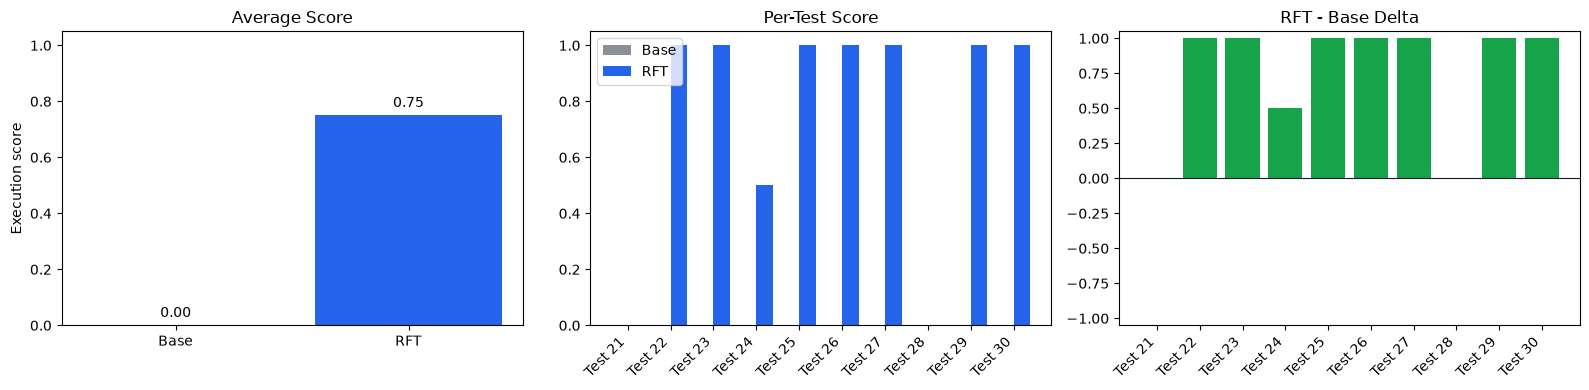

In [11]:
if not score_rows:
    print("No scores to plot yet. Run the RFT/base cells first.")
else:
    names = [row["name"] for row in score_rows]
    rft_scores = [row["rft"] for row in score_rows]
    has_base_plot = all(row["base"] is not None for row in score_rows)

    if has_base_plot:
        base_scores = [row["base"] for row in score_rows]
        deltas = [row["delta"] for row in score_rows]

        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        axes[0].bar(["Base", "RFT"], [avg_base, avg_rft], color=["#8a8f98", "#2563eb"])
        axes[0].set_ylim(0, 1.05)
        axes[0].set_title("Average Score")
        axes[0].set_ylabel("Execution score")
        for idx, value in enumerate([avg_base, avg_rft]):
            axes[0].text(idx, value + 0.03, f"{value:.2f}", ha="center")

        x = range(len(names))
        width = 0.38
        axes[1].bar([i - width / 2 for i in x], base_scores, width=width, label="Base", color="#8a8f98")
        axes[1].bar([i + width / 2 for i in x], rft_scores, width=width, label="RFT", color="#2563eb")
        axes[1].set_ylim(0, 1.05)
        axes[1].set_title("Per-Test Score")
        axes[1].set_xticks(list(x))
        axes[1].set_xticklabels(names, rotation=45, ha="right")
        axes[1].legend()

        colors = ["#16a34a" if d > 0 else "#dc2626" if d < 0 else "#8a8f98" for d in deltas]
        axes[2].bar(list(x), deltas, color=colors)
        axes[2].axhline(0, color="#111827", linewidth=0.8)
        axes[2].set_ylim(-1.05, 1.05)
        axes[2].set_title("RFT - Base Delta")
        axes[2].set_xticks(list(x))
        axes[2].set_xticklabels(names, rotation=45, ha="right")

        plt.tight_layout()
        plt.show()
    else:
        fig, ax = plt.subplots(figsize=(10, 4))
        x = range(len(names))
        ax.bar(list(x), rft_scores, color="#2563eb")
        ax.set_ylim(0, 1.05)
        ax.set_title(f"RFT Scores, Average = {avg_rft:.2f}")
        ax.set_ylabel("Execution score")
        ax.set_xticks(list(x))
        ax.set_xticklabels(names, rotation=45, ha="right")
        for idx, value in enumerate(rft_scores):
            ax.text(idx, value + 0.03, f"{value:.1f}", ha="center")
        plt.tight_layout()
        plt.show()


## 9. Try Your Own Query

Use this final section for ad hoc prompts after the evaluation run. It sends your custom SQL-correction request to the RFT model, and optionally the base model if configured, then executes and displays the generated SQL.

In [12]:
custom_prompt = """Intent: Get the average order amount per user plan type for completed orders.

Query:
SELECT u.plan, AVG(o.amount)
FROM users u
JOIN orders o ON u.id = o.user_id
WHERE status = 'completed'"""

# Run RFT, and optionally BASE if FIREWORKS_BASE_MODEL is set.
models_to_run = [(RFT_MODEL, "RFT")]
if BASE_MODEL:
    models_to_run.insert(0, (BASE_MODEL, "BASE"))

for model_id, label in models_to_run:
    response = call_model(model_id, custom_prompt, temperature=0.0)
    print_result(label, response)



 BASE

📝 REASONING:
The query is close to achieving the intended behavior, but it's missing a crucial aspect: filtering the orders by plan type. The query currently returns the average order amount for all users, regardless of their plan type. To fix this, we need to join the orders table with the order_items table to get the product information, and then join the order_items table with the products table to get the product category. We can then group the results by user plan type and calculate the average order amount for each plan type.

🔧 CORRECTED SQL:
(no SQL found)

❌ EXECUTION ERROR: near "(": syntax error

 RFT

📝 REASONING:
The query is close to achieving the intended behavior, but it's missing a crucial aspect: filtering the orders by plan type. The query currently returns the average order amount for all users, regardless of their plan type. To fix this, we need to join the orders table with the order_items table to get the product information, and then group the results by